````{margin}
```{attributiongrey} Attribution
:class: attribution

This page is adapted from https://github.com/twrijsdijk/Examples-for-the-use-of-springs-in-SymPy/blob/main/VB_Rotatieveer_Midden.py

```
```` 


# Voorbeeld rotatieveer midden

In [ ]:
%pip install git+https://github.com/twrijsdijk/sympy

belasting 125*SingularityFunction(x, 0, -1) + 750*SingularityFunction(x, 3, -3) - 250*SingularityFunction(x, 3, -1) + 125*SingularityFunction(x, 6, -1)
Dwarskrachten -125*SingularityFunction(x, 0, 0) - 750*SingularityFunction(x, 3, -2) + 250*SingularityFunction(x, 3, 0) - 125*SingularityFunction(x, 6, 0)
Reactiekrachten {R_6: 125, R_0: 125}
Moment -125*SingularityFunction(x, 0, 1) - 750*SingularityFunction(x, 3, -1) + 250*SingularityFunction(x, 3, 1) - 125*SingularityFunction(x, 6, 1)
Hoeverdraaiing 5*SingularityFunction(x, 0, 2)/32 + 15*SingularityFunction(x, 3, 0)/8 - 5*SingularityFunction(x, 3, 2)/16 + 5*SingularityFunction(x, 6, 2)/32 - 75/32
Doorbuiging -75*x/32 + 5*SingularityFunction(x, 0, 3)/96 + 15*SingularityFunction(x, 3, 1)/8 - 5*SingularityFunction(x, 3, 3)/48 + 5*SingularityFunction(x, 6, 3)/96


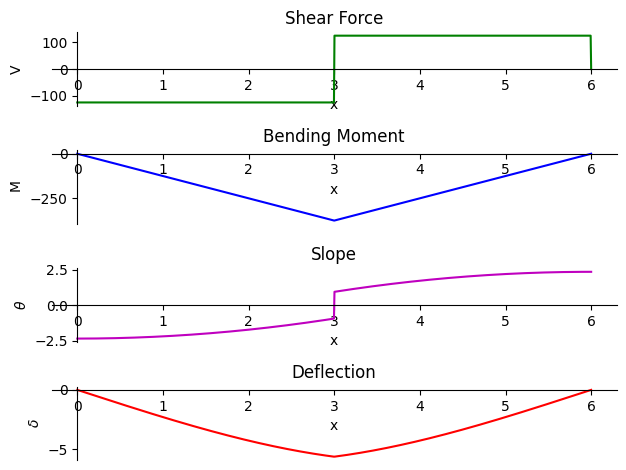

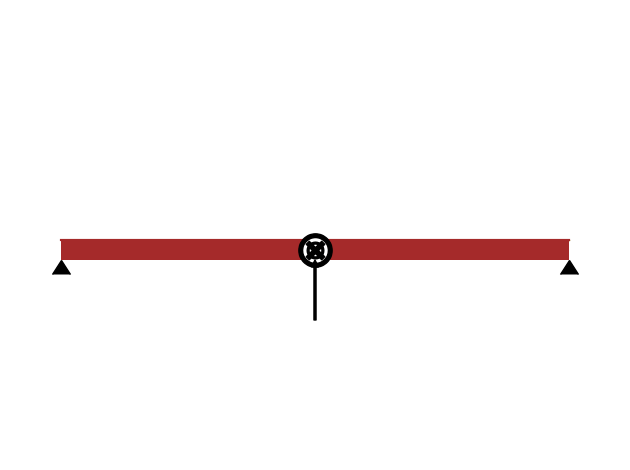

In [5]:
from sympy.physics.continuum_mechanics import Beam
from sympy import symbols
E, I, k = symbols(['E','I','k'])
#Omschrijving van de balk
b = Beam(6, 20, 20)
r0 = b.apply_support(0,'pin')
r6 = b.apply_support(6,'pin')
b.apply_load(-250, 3, -1)
b.apply_rotation_spring(3, 200)

#berekeningen
b.solve_for_reaction_loads(r0, r6)
print('belasting', b.load)
print('Dwarskrachten', b.shear_force())
print('Reactiekrachten', b.reaction_loads)
print('Moment',b.bending_moment())
print('Hoeverdraaiing',b.slope())
print('Doorbuiging',b.deflection())

#plots
axes = b.plot_loading_results()

d = b.draw()
d.show();